# PCA Relative Value Butterfly Backtest

Implements the PCA fly workflow from the attached research notes:

1. Run rolling covariance PCA on swap-rate levels across a configurable spot/forward surface.
2. Find rich/cheap belly-vs-wing candidates from out-of-sample PCA residual Z-scores.
3. Build trade-specific PC3 butterfly weights, normalized to belly risk of 1.0 and neutral to PC1/PC2.
4. Fit OU mean-reversion on the PCA-weighted fly, then filter by Z-score, ADF p-value, half-life, and profit/cost.
5. Execute the strategy through `QueryDrivenBacktest` with a business-day time grid so every open fly is marked to market daily.

The key correction versus the older notebook path is that the executed IRS fly query uses `risk_weights`, not a notebook-only `weights` key.

## 1. Parameters

In [4]:
# All strategy/backtest controls are centralized here. Override values in this dict
# before running the notebook, or pass a modified copy into build_params().
PARAMS = {
    # Data and curve source
    "curve": "USD-SOFR-1D",
    "source": "ERIS_EOD_LIVE-RL_BASIC",
    "data_start": "2022-01-03",
    "data_end": "2026-05-05",
    "backtest_start": "2024-01-02",
    "backtest_end": "2026-03-20",
    "tz": "America/New_York",
    "freq": "nyc_eod",

    # PCA universe. Set curve_input_mode to:
    #   "spot" for one spot curve panel,
    #   "forward_stanchart" for spot plus separate forward-start panels,
    #   "forward_cs" for non-overlapping forward-rate tenors.
    "curve_input_mode": "forward_stanchart",
    "spot_tenors": ["2Y", "3Y", "5Y", "7Y", "10Y", "20Y"],
    "forward_starts": [None, "6M", "9M", "1Y", "2Y", "3Y", "5Y", "10Y"],
    # "cs_forward_tenors": ["1Y", "1Yx1Y", "2Yx1Y", "3Yx1Y", "4Yx1Y", "5Yx1Y", "7Yx3Y", "10Yx5Y", "15Yx5Y", "20Yx10Y"],

    # PCA and residual windows. Lower these for fast research iteration; raise them
    # toward 260/520 business days for production-style runs.
    "pca_window_days": 252,
    "zscore_lookback_days": 126,
    "ou_window_days": 252,
    "pca_input": "levels",
    "n_components": 3,

    # Candidate scan and mean-reversion filters
    "auto_scan_fly": False,
    "fly_universe": [
        ("2Y", "3Y", "5Y"),
        ("3Y", "5Y", "7Y"),
        ("3Y", "5Y", "10Y"),
        ("5Y", "7Y", "10Y"),
        ("5Y", "10Y", "20Y"),
        ("10Y", "20Y", "30Y"),
    ],
    "min_zscore_belly": 1.0,
    "min_zscore_wing": 0.25,
    "max_adf_pvalue": 0.20,
    "min_half_life_days": 3.0,
    "max_half_life_days": 120.0,
    "min_profit_cost_ratio": 1.5,
    "round_trip_cost_bps": 1,

    # Trade construction and portfolio controls
    "include_carry_roll": True,
    "carry_horizon": "1M",
    "trade_belly_bpv": 100_000.0,
    "max_concurrent_positions": 5,

    # Execution controls
    "n_jobs": 8,
    "show_progress": False,
    "cache_only": True,
    "run_sensitivity": False,
    "sensitivity_grid": {
        "pca_window_days": [126, 252],
        "min_zscore_belly": [1.0, 1.5],
        "max_half_life_days": [60.0, 120.0],
    },
}

PARAMS

{'curve': 'USD-SOFR-1D',
 'source': 'ERIS_EOD_LIVE-RL_BASIC',
 'data_start': '2022-01-03',
 'data_end': '2026-05-05',
 'backtest_start': '2024-01-02',
 'backtest_end': '2026-03-20',
 'tz': 'America/New_York',
 'freq': 'nyc_eod',
 'curve_input_mode': 'forward_stanchart',
 'spot_tenors': ['2Y', '3Y', '5Y', '7Y', '10Y', '20Y'],
 'forward_starts': [None, '6M', '9M', '1Y', '2Y', '3Y', '5Y', '10Y'],
 'pca_window_days': 252,
 'zscore_lookback_days': 126,
 'ou_window_days': 252,
 'pca_input': 'levels',
 'n_components': 3,
 'auto_scan_fly': False,
 'fly_universe': [('2Y', '3Y', '5Y'),
  ('3Y', '5Y', '7Y'),
  ('3Y', '5Y', '10Y'),
  ('5Y', '7Y', '10Y'),
  ('5Y', '10Y', '20Y'),
  ('10Y', '20Y', '30Y')],
 'min_zscore_belly': 1.0,
 'min_zscore_wing': 0.25,
 'max_adf_pvalue': 0.2,
 'min_half_life_days': 3.0,
 'max_half_life_days': 120.0,
 'min_profit_cost_ratio': 1.5,
 'round_trip_cost_bps': 1,
 'include_carry_roll': True,
 'carry_horizon': '1M',
 'trade_belly_bpv': 100000.0,
 'max_concurrent_positio

## 2. Imports And Configuration

In [7]:
import datetime as dt
import itertools
import os
import sys
import warnings
from dataclasses import replace
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import nest_asyncio
nest_asyncio.apply()
os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
os.environ.setdefault("ARBS_CACHE_DIR", str((Path.cwd() / ".cache").resolve()))

# Make the notebook robust when launched from either repo root or the notebook dir.
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "BT").exists() and (candidate / "Query").exists():
            return candidate
    raise RuntimeError("Could not find ARBS repo root")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from BT.data_handler import TimeGrid
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.signals.irswap_pca_rv_scanner import (
    IRSwapPCARVConfig,
    analyze_candidates,
    build_carry_roll_queries,
    build_rate_queries,
    build_signal_table,
    identify_candidates,
    reshape_carry_roll_panel,
    reshape_rates_panel,
    scan_surface,
    zscore_snapshot,
)
from BT.signals.irswap_pca_rv_triggers import IRSwapPCARVTrigger
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

plt.style.use("ggplot")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def _parse_date(value, tz_name: str) -> dt.datetime:
    ts = pd.Timestamp(value)
    if ts.tzinfo is None:
        ts = ts.tz_localize(tz_name)
    else:
        ts = ts.tz_convert(tz_name)
    return ts.to_pydatetime()

def _with_tz_naive_index(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    idx = pd.DatetimeIndex(pd.to_datetime(out.index))
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    out.index = idx
    return out


def _as_config(params: dict) -> IRSwapPCARVConfig:
    return IRSwapPCARVConfig(
        curve=params["curve"],
        source=params["source"],
        curve_input_mode=params["curve_input_mode"],
        spot_tenors=list(params["spot_tenors"]),
        forward_starts=list(params["forward_starts"]),
        # cs_forward_tenors=list(params["cs_forward_tenors"]),
        pca_window_days=int(params["pca_window_days"]),
        zscore_lookback_days=int(params["zscore_lookback_days"]),
        ou_window_days=int(params["ou_window_days"]),
        pca_input=params["pca_input"],
        n_components=int(params["n_components"]),
        auto_scan_fly=bool(params["auto_scan_fly"]),
        fly_universe=list(params["fly_universe"]),
        min_zscore_belly=float(params["min_zscore_belly"]),
        min_zscore_wing=float(params["min_zscore_wing"]),
        max_adf_pvalue=float(params["max_adf_pvalue"]),
        min_half_life_days=float(params["min_half_life_days"]),
        max_half_life_days=float(params["max_half_life_days"]),
        min_profit_cost_ratio=float(params["min_profit_cost_ratio"]),
        round_trip_cost_bps=float(params["round_trip_cost_bps"]),
        include_carry_roll=bool(params["include_carry_roll"]),
        carry_horizon=params["carry_horizon"],
        trade_belly_bpv=float(params["trade_belly_bpv"]),
        max_concurrent_positions=int(params["max_concurrent_positions"]),
    )


def build_params(overrides: dict | None = None) -> tuple[dict, IRSwapPCARVConfig]:
    params = dict(PARAMS)
    if overrides:
        params.update(overrides)
    return params, _as_config(params)

params, config = build_params()
tz_name = params["tz"]
data_start = _parse_date(params["data_start"], tz_name)
data_end = _parse_date(params["data_end"], tz_name)
bt_start = _parse_date(params["backtest_start"], tz_name)
bt_end = _parse_date(params["backtest_end"], tz_name)

print(f"Repo root: {REPO_ROOT}")
print(f"Curve: {config.curve} / {config.source}")
print(f"Mode: {config.curve_input_mode}; spot tenors={config.spot_tenors}; forwards={config.forward_starts}")
print(f"Windows: PCA={config.pca_window_days}, zscore={config.zscore_lookback_days}, OU={config.ou_window_days}")
print(f"Filters: belly z>={config.min_zscore_belly}, wing z>={config.min_zscore_wing}, ADF<={config.max_adf_pvalue}, half-life={config.min_half_life_days}-{config.max_half_life_days}d")

Repo root: C:\Users\chris\clee\ARBS
Curve: USD-SOFR-1D / ERIS_EOD_LIVE-RL_BASIC
Mode: forward_stanchart; spot tenors=['2Y', '3Y', '5Y', '7Y', '10Y', '20Y']; forwards=[None, '6M', '9M', '1Y', '2Y', '3Y', '5Y', '10Y']
Windows: PCA=252, zscore=126, OU=252
Filters: belly z>=1.0, wing z>=0.25, ADF<=0.2, half-life=3.0-120.0d


## 3. Load Swap Rate And Carry/Roll Panels

In [8]:
curve_mdp = IRSwapsMDP(source=config.source)
ts_builder = TimeseriesBuilder()
router = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=params["show_progress"])}

rate_queries = build_rate_queries(config)
print(f"Fetching {len(rate_queries)} rate queries...")
rates_df = ts_builder.get_timeseries(
    start=data_start,
    end=data_end,
    queries=rate_queries,
    n_jobs=params["n_jobs"],
    routers=router,
    freq=params["freq"],
    ignore_cache_miss=params["cache_only"],
)
rates_df = _with_tz_naive_index(rates_df.sort_index())
panels = reshape_rates_panel(rates_df, config)

if not panels:
    raise RuntimeError("No rate panels were loaded; check source, curve, tenors, and date range")

print(f"Rates shape: {rates_df.shape}; loaded panels: {list(panels.keys())}")
for fwd, panel in panels.items():
    valid = panel.dropna(how="all")
    label = fwd or "Spot"
    print(f"  {label:>6}: {panel.shape}, valid {valid.index.min()} to {valid.index.max()}")

carry_roll_panels = None
if config.include_carry_roll:
    carry_roll_queries = build_carry_roll_queries(config)
    print(f"Fetching {len(carry_roll_queries)} carry/roll queries...")
    carry_roll_df = ts_builder.get_timeseries(
        start=data_start,
        end=data_end,
        queries=carry_roll_queries,
        n_jobs=params["n_jobs"],
        routers=router,
        freq=params["freq"],
        ignore_cache_miss=params["cache_only"],
    )
    carry_roll_df = _with_tz_naive_index(carry_roll_df.sort_index())
    carry_roll_panels = reshape_carry_roll_panel(carry_roll_df, config)
    print(f"Carry/roll shape: {carry_roll_df.shape}; panels: {list(carry_roll_panels.keys())}")
else:
    carry_roll_df = pd.DataFrame(index=rates_df.index)
    print("Carry/roll disabled")

Fetching 48 rate queries...
Rates shape: (1051, 12); loaded panels: [None, '1Y']
    Spot: (1051, 6), valid 2022-01-03 17:00:00 to 2026-03-19 17:00:00
      1Y: (1051, 6), valid 2022-01-03 17:00:00 to 2026-03-19 17:00:00
Fetching 96 carry/roll queries...
Carry/roll shape: (0, 0); panels: []


## 4. Stage 1: Rolling PCA Surface Scan

Latest residual Z-score snapshot (positive=cheap/high vs PCA fair value, negative=rich/low):


,Spot,1Y
2Y,4.22,3.60
3Y,-2.88,-3.19
5Y,-4.50,-3.59
7Y,-4.29,1.65
10Y,3.46,4.23
20Y,0.88,-4.07


Latest variance explained:


Spot                   1Y              
            PC1    PC2    PC3    PC1    PC2    PC3
variance  0.892  0.097  0.009  0.886  0.109  0.005

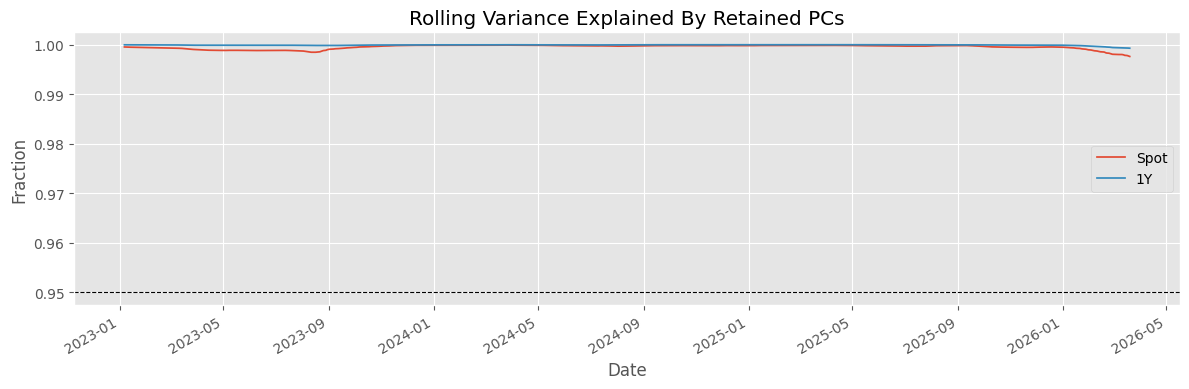

In [9]:
scan_result = scan_surface(panels, config)
snapshot = zscore_snapshot(scan_result)
print("Latest residual Z-score snapshot (positive=cheap/high vs PCA fair value, negative=rich/low):")
display(snapshot.round(2))

ve_frames = []
for fwd, ve in scan_result.variance_explained.items():
    ve_valid = ve.dropna(how="all")
    if not ve_valid.empty:
        tmp = ve_valid.copy()
        tmp.columns = pd.MultiIndex.from_product([[fwd or "Spot"], tmp.columns])
        ve_frames.append(tmp)

if ve_frames:
    ve_panel = pd.concat(ve_frames, axis=1).sort_index()
    latest_ve = ve_panel.dropna(how="all").iloc[-1]
    print("Latest variance explained:")
    display(latest_ve.to_frame("variance").T.round(3))

    fig, ax = plt.subplots(figsize=(12, 4))
    for fwd, ve in scan_result.variance_explained.items():
        ve_valid = ve.dropna(how="all")
        if not ve_valid.empty:
            ve_valid.sum(axis=1).plot(ax=ax, label=fwd or "Spot", linewidth=1.25)
    ax.set_title("Rolling Variance Explained By Retained PCs")
    ax.set_ylabel("Fraction")
    ax.axhline(0.95, color="black", linewidth=0.8, linestyle="--")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

## 5. Stages 2-4: Candidates, OU Analytics, And Signal Table

In [10]:
latest_candidates = identify_candidates(scan_result, panels, config)
latest_trades = analyze_candidates(latest_candidates, panels, config, carry_roll_panels)
print(f"Latest candidates: {len(latest_candidates)}; analyzed trades: {len(latest_trades)}")

if latest_trades:
    latest_trade_df = pd.DataFrame([
        {
            "forward": t.candidate.forward_start or "Spot",
            "fly": "/".join(t.candidate.tenors),
            "direction": t.candidate.direction,
            "weights": tuple(round(x, 4) for x in t.candidate.weights),
            "z_belly": t.candidate.zscore_belly,
            "z_left": t.candidate.zscore_left,
            "z_right": t.candidate.zscore_right,
            "level_bps": t.current_level * 10_000,
            "target_bps": t.target_level * 10_000,
            "stop_bps": t.stop_loss_level * 10_000,
            "half_life_days": t.half_life_days,
            "horizon_days": t.investment_horizon_days,
            "adf_pvalue": t.adf_pvalue,
            "carry_roll_bps": t.carry_roll_bps,
            "profit_cost": t.profit_cost_ratio,
            "passes": t.passes_filter,
            "filter_reasons": "; ".join(t.filter_reasons),
        }
        for t in latest_trades
    ])
    display(latest_trade_df.sort_values(["passes", "profit_cost"], ascending=[False, False]).round(3))
else:
    print("No latest-date trades passed candidate analysis; rolling backtest may still find historical entries.")

print("Building rolling signal table...")
signal_table = build_signal_table(
    panels=panels,
    config=config,
    carry_roll_panels=carry_roll_panels,
    start_date=pd.Timestamp(bt_start).tz_localize(None),
    end_date=pd.Timestamp(bt_end).tz_localize(None),
)

total_signals = sum(len(v) for v in signal_table.values())
passing_signals = sum(sum(1 for t in trades if t.passes_filter) for trades in signal_table.values())
print(f"Signal dates: {len(signal_table)}; total analyzed signals: {total_signals}; passing filters: {passing_signals}")

signal_summary_rows = []
for signal_date, trades in signal_table.items():
    for t in trades:
        signal_summary_rows.append({
            "date": pd.Timestamp(signal_date),
            "forward": t.candidate.forward_start or "Spot",
            "fly": "/".join(t.candidate.tenors),
            "direction": t.candidate.direction,
            "lifetime_z": t.lifetime_zscore,
            "profit_cost": t.profit_cost_ratio,
            "half_life_days": t.half_life_days,
            "adf_pvalue": t.adf_pvalue,
            "passes": t.passes_filter,
        })

signals_df = pd.DataFrame(signal_summary_rows)
if not signals_df.empty:
    display(signals_df.sort_values("date").tail(20).round(3))
else:
    print("No signals were generated for the configured backtest window.")

arbitragelab OU half_life=17467309.0d (mu_ann=0.000010), using AR(1) fallback
arbitragelab OU fit failed, using AR(1) fallback: Implausible half_life from arbitragelab


Latest candidates: 1; analyzed trades: 1


,forward,fly,direction,weights,z_belly,z_left,z_right,level_bps,target_bps,stop_bps,half_life_days,horizon_days,adf_pvalue,carry_roll_bps,profit_cost,passes,filter_reasons
0,1Y,5Y/10Y/20Y,receive_belly,"(-0.5329, 1.0, -0.4769)",4.232,-3.586,-4.069,-209.701,66.603,-347.852,16.352,49.055,0.539,0.0,92.101,False,adf_pvalue=0.539 > 0.2


Building rolling signal table...


arbitragelab OU half_life=17467309.0d (mu_ann=0.000010), using AR(1) fallback
arbitragelab OU fit failed, using AR(1) fallback: Implausible half_life from arbitragelab
arbitragelab OU half_life=17467309.0d (mu_ann=0.000010), using AR(1) fallback
arbitragelab OU fit failed, using AR(1) fallback: Implausible half_life from arbitragelab
arbitragelab OU half_life=17467309.0d (mu_ann=0.000010), using AR(1) fallback
arbitragelab OU fit failed, using AR(1) fallback: Implausible half_life from arbitragelab
arbitragelab OU half_life=17467309.0d (mu_ann=0.000010), using AR(1) fallback
arbitragelab OU fit failed, using AR(1) fallback: Implausible half_life from arbitragelab
arbitragelab OU half_life=17467309.0d (mu_ann=0.000010), using AR(1) fallback
arbitragelab OU fit failed, using AR(1) fallback: Implausible half_life from arbitragelab
arbitragelab OU half_life=17467309.0d (mu_ann=0.000010), using AR(1) fallback
arbitragelab OU fit failed, using AR(1) fallback: Implausible half_life from arbit

Signal dates: 303; total analyzed signals: 393; passing filters: 151


,date,forward,fly,direction,lifetime_z,profit_cost,half_life_days,adf_pvalue,passes
373,2026-02-27 17:00:00,1Y,2Y/3Y/5Y,pay_belly,0.311,4.993,4.745,0.035,True
374,2026-03-02 17:00:00,Spot,5Y/10Y/20Y,receive_belly,-0.919,93.927,66.902,0.778,False
375,2026-03-03 17:00:00,Spot,5Y/10Y/20Y,receive_belly,-0.932,93.674,63.239,0.783,False
376,2026-03-04 17:00:00,Spot,5Y/10Y/20Y,receive_belly,-0.912,94.804,66.472,0.769,False
377,2026-03-04 17:00:00,1Y,5Y/10Y/20Y,receive_belly,-1.495,64.115,16.291,0.421,False
378,2026-03-05 17:00:00,Spot,5Y/10Y/20Y,receive_belly,-1.088,114.084,66.124,0.755,False
379,2026-03-05 17:00:00,1Y,5Y/10Y/20Y,receive_belly,-1.633,68.969,15.723,0.374,False
381,2026-03-06 17:00:00,1Y,5Y/10Y/20Y,receive_belly,-1.495,60.807,14.540,0.409,False
380,2026-03-06 17:00:00,Spot,5Y/10Y/20Y,receive_belly,-1.252,124.341,59.229,0.740,False
382,2026-03-09 17:00:00,Spot,5Y/10Y/20Y,receive_belly,-1.183,123.483,64.603,0.769,False


## 6. QueryDrivenBacktest With Daily Mark To Market

In [11]:
bt_start_naive = pd.Timestamp(bt_start).tz_localize(None)
bt_end_naive = pd.Timestamp(bt_end).tz_localize(None)
base_panel = next(iter(panels.values())).dropna(how="all")
bt_index = base_panel.loc[(base_panel.index >= bt_start_naive) & (base_panel.index <= bt_end_naive)].index
bt_datetimes = [pd.Timestamp(d).to_pydatetime() for d in bt_index]
if not bt_datetimes:
    raise RuntimeError("No cached business-day observations are available for the configured backtest window")

trigger = IRSwapPCARVTrigger(signal_table, config)
strategy = QueryStrategy("irswap_pca_rv_fly", triggers=[trigger], default_mdp=curve_mdp)

bt = QueryDrivenBacktest(
    time_grid=TimeGrid(bt_datetimes),
    strategy=strategy,
    mdp=curve_mdp,
    show_progress=params["show_progress"],
    progress_desc="PCA RV FLY BACKTEST",
)

print(f"Running QueryDrivenBacktest over {len(bt_datetimes)} business-day MTM steps")
bt.run()

mtm = pd.Series(bt.mtm_history, dtype=float).sort_index()
realized = pd.Series(bt.realized_pnl_history, dtype=float).sort_index()
positions_by_day = pd.Series({k: len(v) for k, v in bt.position_history.items()}, dtype=float).reindex(mtm.index).fillna(0)

expected_steps = len(bt_datetimes)
actual_steps = len(mtm)
print(f"MTM observations: {actual_steps}/{expected_steps}")
if actual_steps != expected_steps:
    raise RuntimeError("Backtest did not mark every business-day time-grid step")

Running QueryDrivenBacktest over 552 business-day MTM steps
MTM observations: 552/552


## 7. Results

,value
start,2024-01-02 17:00:00
end,2026-03-19 17:00:00
mtm_days,552
entries,64
closed_trades,64
open_positions,0
final_mtm_pnl,-21065304.895201
realized_pnl,-21065304.895201
daily_pnl_mean,-38231.043367
daily_pnl_vol,1736562.557911


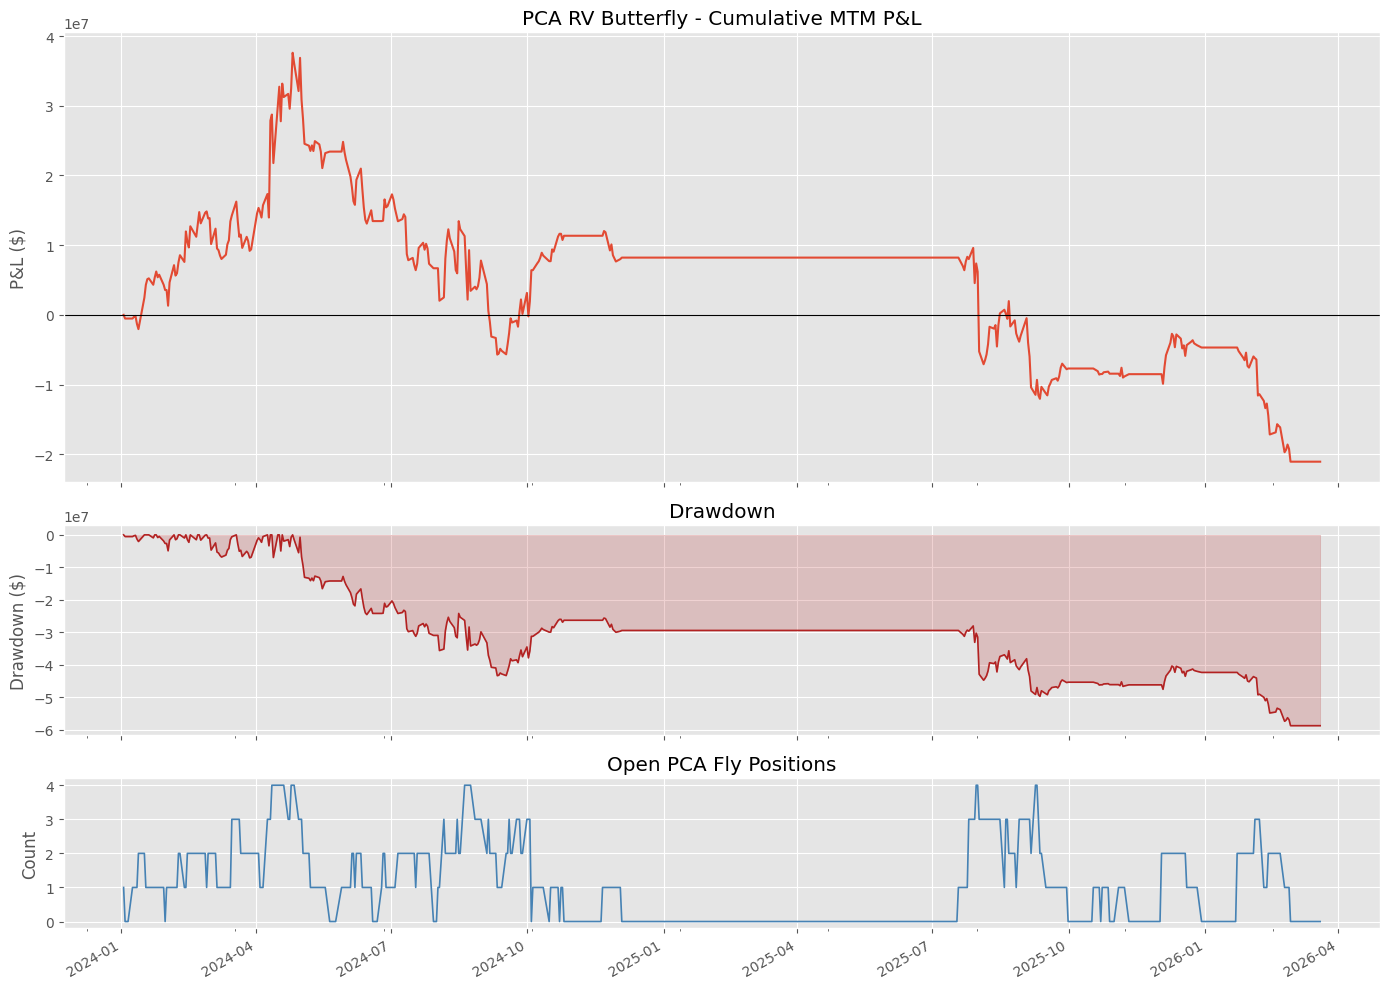

,opened_at,closed_at,holding_period_days,realized_pnl,gross_realized_pnl,fee_allocated,exit_meta,position_meta
44,2025-08-04 17:00:00,2025-08-07 17:00:00,3.0,7.469459e+05,7.469459e+05,0.0,"{'action': 'pca_rv_exit', 'reason': 'stop_loss'}","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."
45,2025-07-30 17:00:00,2025-08-18 17:00:00,19.0,-1.392379e+06,-1.392379e+06,0.0,"{'action': 'pca_rv_exit', 'reason': 'max_holdi...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
46,2025-08-07 17:00:00,2025-08-18 17:00:00,11.0,2.099074e+06,2.099074e+06,0.0,"{'action': 'pca_rv_exit', 'reason': 'max_holdi...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
47,2025-07-30 17:00:00,2025-08-21 17:00:00,22.0,-1.947861e+06,-1.947861e+06,0.0,"{'action': 'pca_rv_exit', 'reason': 'max_holdi...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
48,2025-08-19 17:00:00,2025-08-26 17:00:00,7.0,-1.596379e+06,-1.596379e+06,0.0,"{'action': 'pca_rv_exit', 'reason': 'stop_loss'}","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."
49,2025-08-28 17:00:00,2025-09-05 17:00:00,8.0,-2.165298e+06,-2.165298e+06,0.0,"{'action': 'pca_rv_exit', 'reason': 'stop_loss'}","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
50,2025-09-08 17:00:00,2025-09-10 17:00:00,2.0,-2.689522e+05,-2.689522e+05,0.0,"{'action': 'pca_rv_exit', 'reason': 'stop_loss'}","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
51,2025-09-08 17:00:00,2025-09-11 17:00:00,3.0,-4.085188e+05,-4.085188e+05,0.0,"{'action': 'pca_rv_exit', 'reason': 'stop_loss'}","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."
52,2025-08-19 17:00:00,2025-09-15 17:00:00,27.0,-5.156061e+06,-5.156061e+06,0.0,"{'action': 'pca_rv_exit', 'reason': 'max_holdi...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
53,2025-08-27 17:00:00,2025-09-25 17:00:00,29.0,1.324502e+06,1.324502e+06,0.0,"{'action': 'pca_rv_exit', 'reason': 'max_holdi...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."


,timestamp,query,meta
44,2025-07-30 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
45,2025-07-30 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
46,2025-08-04 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."
47,2025-08-07 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
48,2025-08-19 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
49,2025-08-19 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."
50,2025-08-27 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."
51,2025-08-28 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."
52,2025-09-08 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_sp..."
53,2025-09-08 17:00:00,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_1Y..."


BACKTEST_METRICS {'start': Timestamp('2024-01-02 17:00:00'), 'end': Timestamp('2026-03-19 17:00:00'), 'mtm_days': 552, 'entries': 64, 'closed_trades': 64, 'open_positions': 0, 'final_mtm_pnl': -21065304.895201236, 'realized_pnl': -21065304.895201236, 'daily_pnl_mean': -38231.04336697139, 'daily_pnl_vol': 1736562.5579109953, 'sharpe': -0.34948294600988183, 'max_drawdown': -58673349.244739145, 'daily_hit_rate': 0.26497277676951, 'closed_trade_hit_rate': 0.421875}


In [12]:
def summarize_backtest(bt, mtm: pd.Series) -> dict:
    daily_pnl = mtm.diff().dropna()
    drawdown = mtm - mtm.cummax()
    closed = pd.DataFrame(bt.portfolio.closed_positions_log)
    entries = len(bt.portfolio.trades_log)
    exits = len(closed)
    wins = None
    if not closed.empty and "realized_pnl" in closed:
        wins = float((closed["realized_pnl"] > 0).mean())
    return {
        "start": mtm.index.min(),
        "end": mtm.index.max(),
        "mtm_days": int(len(mtm)),
        "entries": int(entries),
        "closed_trades": int(exits),
        "open_positions": int(len(bt.portfolio.positions)),
        "final_mtm_pnl": float(mtm.iloc[-1]) if len(mtm) else 0.0,
        "realized_pnl": float(bt.realized_pnl),
        "daily_pnl_mean": float(daily_pnl.mean()) if len(daily_pnl) else 0.0,
        "daily_pnl_vol": float(daily_pnl.std()) if len(daily_pnl) else 0.0,
        "sharpe": float(daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)) if len(daily_pnl) and daily_pnl.std() > 0 else 0.0,
        "max_drawdown": float(drawdown.min()) if len(drawdown) else 0.0,
        "daily_hit_rate": float((daily_pnl > 0).mean()) if len(daily_pnl) else 0.0,
        "closed_trade_hit_rate": wins,
    }

metrics = summarize_backtest(bt, mtm)
metrics_df = pd.Series(metrics, name="value").to_frame()
display(metrics_df)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1.4, 1]})
mtm.plot(ax=axes[0], title="PCA RV Butterfly - Cumulative MTM P&L", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("P&L ($)")

drawdown = mtm - mtm.cummax()
drawdown.plot(ax=axes[1], title="Drawdown", color="firebrick", linewidth=1.2)
axes[1].fill_between(drawdown.index, drawdown.values, 0, color="firebrick", alpha=0.2)
axes[1].set_ylabel("Drawdown ($)")

positions_by_day.plot(ax=axes[2], title="Open PCA Fly Positions", color="steelblue", linewidth=1.2)
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

closed_positions = pd.DataFrame(bt.portfolio.closed_positions_log)
if not closed_positions.empty:
    cols = [c for c in ["opened_at", "closed_at", "holding_period_days", "realized_pnl", "gross_realized_pnl", "fee_allocated", "exit_meta", "position_meta"] if c in closed_positions.columns]
    display(closed_positions[cols].tail(20))
else:
    print("No positions were closed during the configured backtest window.")

trade_log = pd.DataFrame([
    {
        "timestamp": getattr(order, "timestamp", None),
        "query": str(getattr(order, "query", "")),
        "meta": getattr(order, "meta", {}),
    }
    for order in bt.portfolio.trades_log
])
if not trade_log.empty:
    display(trade_log.tail(20))
else:
    print("No entries were executed during the configured backtest window.")

print("BACKTEST_METRICS", metrics)

## 8. Optional Sensitivity Grid

In [13]:
def run_configured_backtest(param_overrides: dict) -> dict:
    local_params, local_config = build_params(param_overrides)
    local_signal_table = build_signal_table(
        panels=panels,
        config=local_config,
        carry_roll_panels=carry_roll_panels if local_config.include_carry_roll else None,
        start_date=pd.Timestamp(bt_start).tz_localize(None),
        end_date=pd.Timestamp(bt_end).tz_localize(None),
    )
    local_trigger = IRSwapPCARVTrigger(local_signal_table, local_config)
    local_strategy = QueryStrategy("irswap_pca_rv_fly_sensitivity", triggers=[local_trigger], default_mdp=curve_mdp)
    local_bt = QueryDrivenBacktest(
        time_grid=TimeGrid(bt_datetimes),
        strategy=local_strategy,
        mdp=curve_mdp,
        show_progress=False,
    )
    local_bt.run()
    local_mtm = pd.Series(local_bt.mtm_history, dtype=float).sort_index()
    out = summarize_backtest(local_bt, local_mtm)
    out.update(param_overrides)
    out["signal_dates"] = len(local_signal_table)
    out["passing_signals"] = sum(sum(1 for t in trades if t.passes_filter) for trades in local_signal_table.values())
    return out

if params["run_sensitivity"]:
    grid = params["sensitivity_grid"]
    keys = list(grid.keys())
    rows = []
    for values in itertools.product(*(grid[k] for k in keys)):
        overrides = dict(zip(keys, values))
        print("Running", overrides)
        rows.append(run_configured_backtest(overrides))
    sensitivity_df = pd.DataFrame(rows)
    display(sensitivity_df.sort_values("sharpe", ascending=False))
else:
    print("Sensitivity grid disabled. Set PARAMS['run_sensitivity'] = True to run it.")

Sensitivity grid disabled. Set PARAMS['run_sensitivity'] = True to run it.
